# Fraud Detection - XGBoost


In this notebook, we train a fraud detection classifier on the credit card dataset retrieved from Kaggle (https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud). The data is at the transaction level, and labels for the confirmed fraud cases are also provided in the dataset. Our objective is to build a model to predict the fraudulent transactions.

The XGBoost classifier achieved a **recall of 53.6% and precision of 71.43%** on the holdout test set, and a **precision of 93.18% and recall of 83.67%** on the validation set. 

| | **Validation** | **Test** |
|---|---|---|
| Precision | 0.932 | 0.714 |
| Recall | 0.837 | 0.536 |

Notably, the model only produced 6 false-negatives in the unseen test set, thanks in part to the cost-conscious parameterization for the classifier threshold -- choosing to tradeoff more tolerance of false-positives, in order to minimize the higher business costs associated with false-negatives (i.e. chargebacks). The XGBoost model outperformed a baseline logistic regression model. 

<br>

![Confusion Matrix](images/confusion_matrix.png)
<br>



### Comparison to Baseline: XGBoost vs Logistic Regression

The charts below show that the XGBoost model outperformed the baseline logistic regression model in both the validation and test sets:
* The precision/recall chart clearly shows the XGBoost model outperforming on the hold out test set
    * The XGBoost model's performance is much more stable in the test set, implying better generalizability on unseen data
* The class distribution by score chart shows that the logistic regression chart is not able to discriminate as strongly as the XGBoost model, and the blue distribution has larger overlap with the orange distribution


![Class Distribution](images/class_distribution_plot.png)

<br>

![Precision-Recall](images/precision_recall.png)

## Techniques
The following techniques are used to build the XGBoost model:
* `TimeSeriesSplit` for selecting the Train/Val/Test splits, to prevent temporal data leakage (i.e. predicting the past with the future)
* Manual initialization of XGBoost's `scale_pos_weight` parameter value to compensate for class imbalances
* Hyperparameter tuning with Optuna TPE algorithm, setting eval metric to `aucpr` 
* Applying a cost-minimization approach to choosing the classifier threshold value, taking into account the cost-asymmetries of false-positives vs. false-negatives

## Contents
1. Exploratory Data Analysis (EDA)
2. Model Sepcification
3. Hyperparameter Tuning
4. Final Model Training
5. Performance Evaluation on Test Set
6. Deploy model on Vertex AI Endpoint

<br>

___


## EDA and Explanation of Features

There's not a lot to say about this dataset, as most of the columns have been stripped of their original meaning via PCA for anonymization. 

`Class` is the target label, which we will attempt to predict. Definitions for the rest of the features are below:

* `Time`: the time in seconds that the transaction occured, after the first transaction in the dataset
* `Amount`: the transaction value 
* `Class`: binary class label, flagging whether the transaction is suspicious or not
* `V*`: attributes of the transaction, processed with PCA to anonymize the data

In [1]:
import os
import pandas as pd
import altair as alt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

df = pd.read_csv("data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [25]:
# Highly imbalanced class labels
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

/Users/smasuno/ai_projects/fraud_detection/src/utils.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  eda_df = df.groupby(['Time', 'Class']).apply(lambda x: x.shape[1]).reset_index()
/var/folders/97/c28tl4xd04jdjvpk8y8ck8yh0000gn/T/ipykernel_80472/1014257854.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  eda_plot1(df).show()


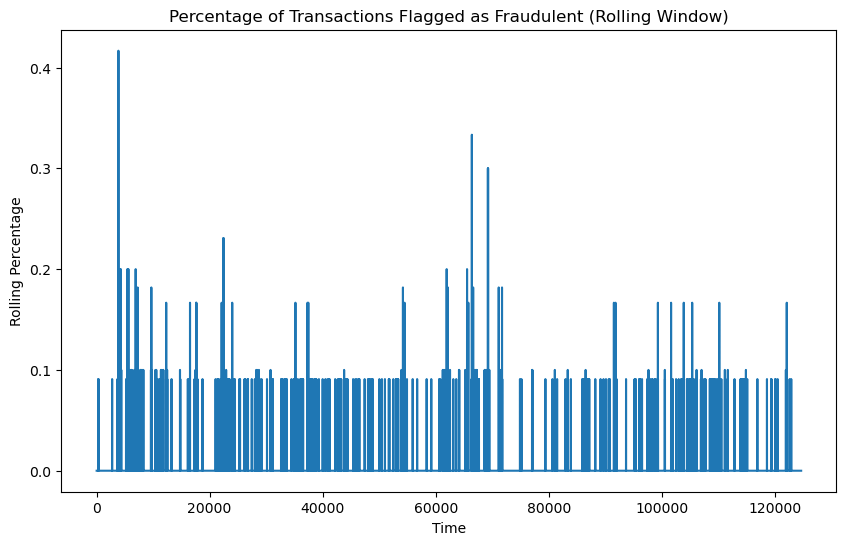

In [2]:
from src.utils import eda_plot1
eda_plot1(df).show()

The charts above shows that fraud activity occurs intermittently (somewhat randomly) over time, but we also see spikes which may suggest events can cluster around certain times. 

T-SNE cluster diagram returned the interesting image below, with the legitimate transactions clustering into a shape resembling a swan (depicted in black, appropriately).

An observation -- the fraud clusters do not form one single cluster in the feature space, suggesting the existence of variations in fraud patterns.   

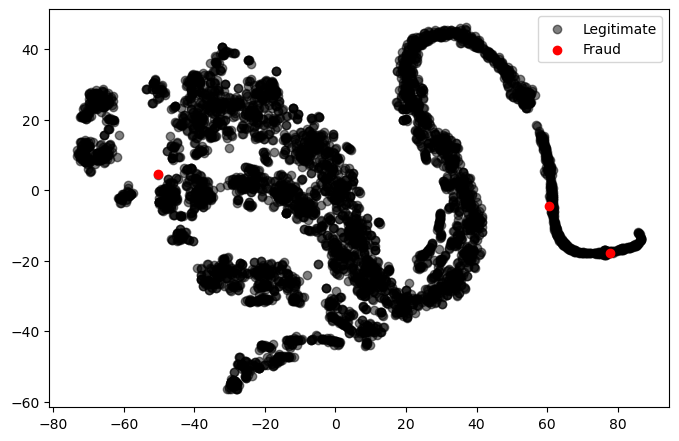

In [150]:
import matplotlib.patheffects as PathEffects
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, init='pca', random_state=12345, perplexity=50)
X_tsne = tsne.fit_transform(X_ts[:5000])

f = plt.figure(figsize=(8,8))
ax = plt.subplot(aspect='equal')
colors = y_ts[:5000]
plt.scatter(X_tsne[colors==0, 0], X_tsne[colors==0, 1], label='Legitimate', alpha=0.5, color='black')
plt.scatter(X_tsne[colors==1, 0], X_tsne[colors==1, 1], label='Fraud', color='red')
plt.legend()

## Model Training - XGBoost

Since there are only 30 input features, we remove the `Time` column and skip feature selection, going straight to hyperparameter tuning.

The XGBoost algorithm will automatically split on the most informative features and ignore the rest, so having a larger feature set than necessary doesn't lead to issues like multicollinearity that we would observe in linear regression. However, it does help to narrow down the input features for explainability reasons, when it becomes very large (i.e. more than 100)   



### Hyperparameter Tuning with Optuna

* The cross-validation splits are created using `TimeSeriesSplit` rather than `train_test_split` in order to prevent temporal data leakage
* Using the `optuna` library, we perform a hyperparameter search with the TPE algorithm 
* The important parameters to pay attention to are: 
    * `scale_pos_weight`: the weighting factor on positive labels, to compensate for the imbalanced classes
    * `eval_metric`: we choose the `aucpr` evaluation metric here intentionally, to maximize the area under the precision-recall curve
    * `min_child_weight`: controls the minimum sum of instance weights in a leaf node
    * `max_delta_step`: constrains the magnitude of each tree's weight update, stabilizing training when class distribution is extreme

We initialize the `scale_pos_weight` variable to the ratio of negative classes to positive classes:

$$
\text{scale\_pos\_weight} = \dfrac{\# Negative Labels}{\# Positive Labels}
$$

In [3]:
import optuna
import xgboost as xgb
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.pipeline import Pipeline
import shap
from sklearn.metrics import average_precision_score, f1_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=10)
df_ts = df.sort_values(by='Time').reset_index(drop=True)
X_ts, y_ts = df_ts.drop(columns=['Class', 'Time']), df_ts['Class']

print(f"scale_pos_weight starting value: {(y_ts == 0).sum() / (y_ts==1).sum():.4f}")

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.0, 10.0),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.0, 10.0),
        'min_child_weight': trial.suggest_float('min_child_weight', 0, 10),
        'objective': 'binary:logistic',
        'use_label_encoder': False,
        'verbosity': 0,
        'n_jobs': -1,
        'random_state': 0,
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 500, 2000),
        'eval_metric': 'aucpr',
        'early_stopping_rounds': 30
    }

    scores = []
    for train_idx, valid_idx in list(tscv.split(X_ts))[:-1]:
        X_train, X_valid = X_ts.iloc[train_idx], X_ts.iloc[valid_idx]
        y_train, y_valid = y_ts.iloc[train_idx], y_ts.iloc[valid_idx]

        clf = xgb.XGBClassifier(**params)
        clf.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            #early_stopping_rounds=30,
            verbose=False
        )
        y_pred = clf.predict_proba(X_valid)[:, 1]
        scores.append(average_precision_score(y_valid, y_pred))

    return np.mean(scores)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=30, n_jobs=1)

[I 2026-05-07 11:43:25,432] A new study created in memory with name: no-name-a4a01687-a5de-4a9d-84c3-68cf472ccac6


scale_pos_weight starting value: 577.8760


[I 2026-05-07 11:43:31,862] Trial 0 finished with value: 0.7799733393646806 and parameters: {'n_estimators': 297, 'max_depth': 8, 'learning_rate': 0.0311256170909018, 'subsample': 0.7724415914984484, 'colsample_bytree': 0.7118273996694524, 'reg_alpha': 6.458941130666561, 'reg_lambda': 4.375872112626925, 'min_child_weight': 8.917730007820797, 'scale_pos_weight': 1945.494140751544}. Best is trial 0 with value: 0.7799733393646806.
[I 2026-05-07 11:43:38,391] Trial 1 finished with value: 0.7155056592570779 and parameters: {'n_estimators': 222, 'max_depth': 9, 'learning_rate': 0.02042381402566498, 'subsample': 0.7840222805469661, 'colsample_bytree': 0.9627983191463305, 'reg_alpha': 0.7103605819788694, 'reg_lambda': 0.8712929970154071, 'min_child_weight': 0.2021839744032572, 'scale_pos_weight': 1748.929768321907}. Best is trial 0 with value: 0.7799733393646806.
[I 2026-05-07 11:43:43,834] Trial 2 finished with value: 0.8089744972037771 and parameters: {'n_estimators': 400, 'max_depth': 9, 'l

### Feature Importance

Taking a look at the SHAP summary, we observe that `V14` and `V4` are the two most influential feaures in the XGBoost model. 

* Higher values of `V14` tend to push the model towards predicting a negative label
* Higher values of `V4` tend to push the model towards predicting a positive label

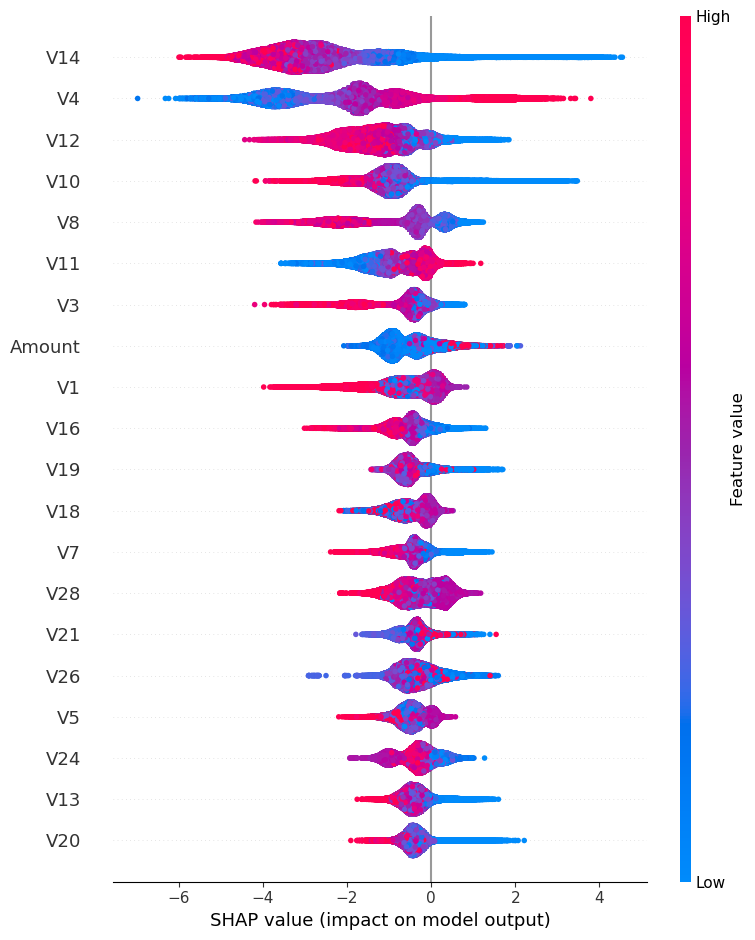

In [24]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)
shap.summary_plot(shap_values, X_train, max_display=20)

### Train Final Model with Best parameters from Hyperparameter Search, on the full Training Set

Using the hyperparameters retrieved from the parameter search, we fit the model onto the full training set:
* The distribution of scores by their actual class label indicates a neat separation. 
* Almost all the legitimate transactions received a score close to 0, while all the transactions with a score greater than 0.2 turned out to be fraudulent.

In [8]:
print('='*50)
print(f"Best PRC Score: {study.best_value:.4f}")
print("Best Parameters: ")
for k, v in study.best_params.items():
    print(f"\t {k}: {v}")
print('='*50)

import pickle

if 'xgb_creditcard.pkl' in os.listdir('models/'):
    with open('models/xgb_creditcard.pkl', 'rb') as file:
        model = pickle.load(file)
else:
    train_idx, valid_idx = list(tscv.split(X_ts))[-2]
    _, test_idx = list(tscv.split(X_ts))[-1]

    X_train, y_train = X_ts.iloc[train_idx], y_ts.iloc[train_idx] 
    X_valid, y_valid = X_ts.iloc[valid_idx], y_ts.iloc[valid_idx]
    X_test, y_test = X_ts.iloc[test_idx], y_ts.iloc[test_idx]

    model = xgb.XGBClassifier(**study.best_params)
    model.fit(X_train, y_train, eval_set=[(X_valid, y_valid)], verbose=100)

    import pickle
    with open('models/xgb_creditcard.pkl', 'wb') as file:
        # Save model
        pickle.dump(model, file)

y_pred = model.predict_proba(X_valid)[:,1]
#y_pred

Best PRC Score: 0.8100
Best Parameters: 
	 n_estimators: 332
	 max_depth: 6
	 learning_rate: 0.27336065499794115
	 subsample: 0.8227856773004942
	 colsample_bytree: 0.748751808296992
	 reg_alpha: 3.544424102127798
	 reg_lambda: 6.486473007756908
	 min_child_weight: 2.157828995717556
	 scale_pos_weight: 1610.8846996368518
[0]	validation_0-logloss:0.75204
[100]	validation_0-logloss:0.00305
[200]	validation_0-logloss:0.00318
[300]	validation_0-logloss:0.00319
[331]	validation_0-logloss:0.00318


array([1.5640254e-07, 2.2953827e-06, 2.7302196e-06, ..., 1.3081317e-06,
       8.5542604e-07, 2.2622190e-07], shape=(25891,), dtype=float32)

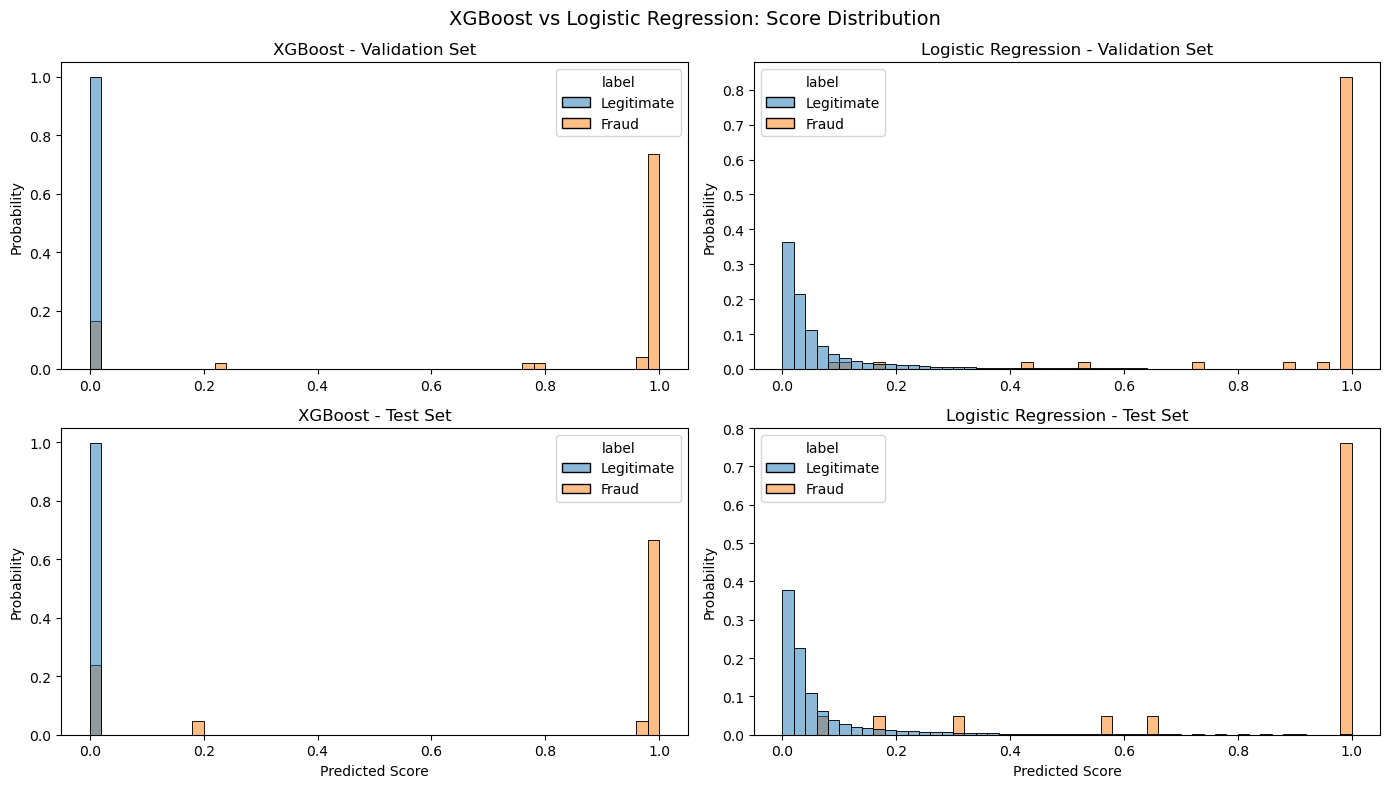

In [158]:
#from src.utils import score_distribution_plot
# score_distribution_plot(y_pred, y_valid)
import seaborn as sns

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(14, 8))

plt.suptitle("XGBoost vs Logistic Regression: Score Distribution", size=14)

plot_df = pd.DataFrame({
    'score': y_pred,
    'class': y_valid
})
plot_df['label'] = np.where(plot_df['class']==1, 'Fraud', 'Legitimate')
#fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=plot_df, x='score', hue='label', stat='probability', common_norm=False, bins=50, alpha=0.5, ax=ax[0,0])
ax[0,0].set_xlabel(None)
ax[0,0].set_title("XGBoost - Validation Set")
#ax[0].legend(loc='upper right')


plot_df = pd.DataFrame({
    'score': model.predict_proba(X_test)[:,1],
    'class': y_test
})
plot_df['label'] = np.where(plot_df['class']==1, 'Fraud', 'Legitimate')
#fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=plot_df, x='score', hue='label', stat='probability', common_norm=False, bins=50, alpha=0.5, ax=ax[1,0])
ax[1,0].set_xlabel("Predicted Score")
ax[1,0].set_title("XGBoost - Test Set")
#plt.tight_layout()
#plt.savefig("images/class_distribution.png")

plot_df = pd.DataFrame({
    'score': logistic_model.predict_proba(X_valid)[:,1],
    'class': y_valid
})
plot_df['label'] = np.where(plot_df['class']==1, 'Fraud', 'Legitimate')
#fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=plot_df, x='score', hue='label', stat='probability', common_norm=False, bins=50, alpha=0.5, ax=ax[0,1])
ax[0,1].set_xlabel(None)
ax[0,1].set_title("Logistic Regression - Validation Set")
#ax[0].legend(loc='upper right')


plot_df = pd.DataFrame({
    'score': logistic_model.predict_proba(X_test)[:,1],
    'class': y_test
})
plot_df['label'] = np.where(plot_df['class']==1, 'Fraud', 'Legitimate')
#fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data=plot_df, x='score', hue='label', stat='probability', common_norm=False, bins=50, alpha=0.5, ax=ax[1,1])
ax[1,1].set_xlabel("Predicted Score")
ax[1,1].set_title("Logistic Regression - Test Set")
plt.tight_layout()
plt.savefig("images/class_distribution_plot.png")

### Precision-Recall Curve

The precision-recall curve shows that we can achieve a precision above 90% and a recall above 80%, on the validation set. 

The shape of the curve indicates a steep drop-off in precision at around the recall=0.82 mark, which should be kept in mind.


	AUCPRC: 0.8483




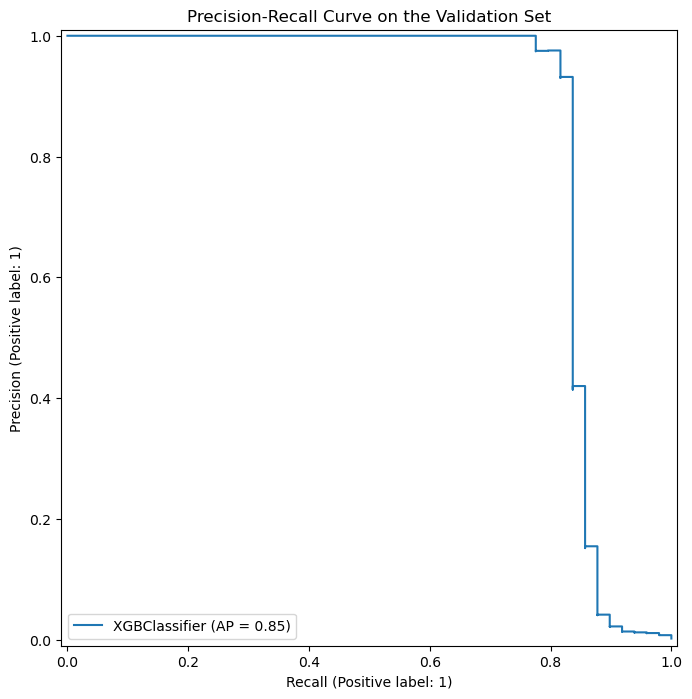

In [11]:
from src.utils import precision_recall_chart1
y_pred = model.predict_proba(X_valid)[:,1]
print('='*50 + '\n')
print(f"\tAUCPRC: {average_precision_score(y_valid, y_pred):.4f}\n")
print('='*50 + '\n')
precision_recall_chart1(model, X_valid, y_valid)

## Cost-Minimization Approach to Selecting the Classifier Threshold Value

Since fraud detection is inherently a problem with an asymmetric cost structure, we select the classifier threshold such that the total cost to the business is minimized. 
* In general, the cost of a false negative (i.e. failing to detect fraud) is usually much higher than the cost of a false positive (i.e. flagging a legitimate transaction as fraud). 
* In the former case, a fraudulent charge can result in chargebacks, lost merchandise, and sometimes investigative fees. 
* In the latter case, an inadvertently denied transaction that turns out to be legitimate results in a missed sales opportunity and possibly churn.  



### Methodology

* Let $C_{FN}$ and $C_{FP}$ be the cost for a false-negative and false-positive respectively
* Let $FN(t)$ and $FP(t)$ be the number of occurrences of a false-negative and false-positive at time $(t)$ respectively
* The cost to the business at time $(t)$ can be represented as below

$$
Cost(t)  = FN(t) \cdot C_{FN} + FP(t) \cdot C_{FP}
$$


* After discussing with our business partners, we agreed on the values below to set for $C_{FN}$ and $C_{FP}$.

$$
C_{FN} = \$150 \\

C_{FP} = \$12
$$

* For each threshold value, we calculate the total cost using the precision and recall arrays and store in a list
* Find the threshold value which corresponds to the lowest cost

In [12]:
from sklearn.metrics import precision_recall_curve
import numpy as np

# Define costs — get these from the business
COST_FALSE_NEGATIVE = 150 # avg fraud loss + chargeback fee per missed fraud
COST_FALSE_POSITIVE = 12 # estimated friction cost per false decline

y_pred = model.predict_proba(X_valid)[:,1]
precisions, recalls, thresholds = precision_recall_curve(y_valid, y_pred)
p, r = precisions[:-1], recalls[:-1]

# Total positives and negatives in val set
n_pos = y_valid.sum()
n_neg = (y_valid == 0).sum()

costs = []
for i, t in enumerate(thresholds):
    if p[i] == 0:
        costs.append(float('inf'))
        continue
    # At threshold t:
    fn = n_pos * (1 - r[i])          # missed fraud cases
    tp = r[i] * n_pos
    fp = tp * (1 - p[i]) / p[i]        # false positives implied by precision
    cost = COST_FALSE_NEGATIVE * fn + COST_FALSE_POSITIVE * fp
    costs.append(cost)

best_idx      = np.argmin(costs)
best_threshold = thresholds[best_idx]
best_cost      = costs[best_idx]

print(f"Optimal threshold: {best_threshold:.3f}")
print(f"Precision at threshold: {precisions[best_idx]:.3f}")
print(f"Recall at threshold:    {recalls[best_idx]:.3f}")
print(f"Expected cost:          ${best_cost:,.0f}")

Optimal threshold: 0.236
Precision at threshold: 0.932
Recall at threshold:    0.837
Expected cost:          $1,236


### Confusion Matrix - Validation Set

On the validation set, using the classifier $(score >= 0.236)$ yields the confusion matrix below. 

> Notably, the model catches 41 (out of 49) actual fraud transactions, while only generating 3 false-positives.

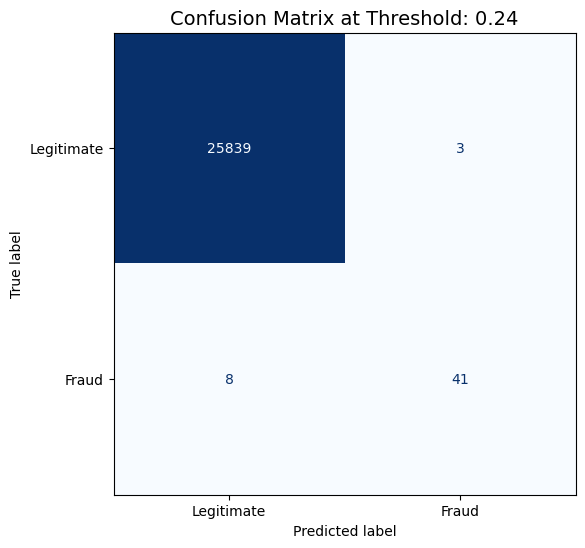

In [13]:
from src.utils import confusion_matrix_chart1
plot_df = pd.DataFrame({
    'score': y_pred,
    'actual': y_valid,
})
plot_df['predicted_class'] = np.where(plot_df['score']>=best_threshold, 1, 0)
confusion_matrix_chart1(plot_df, best_threshold)

## Evaluate the final model on the holdout test set

Finally, we evaluate the model on the holdout test set to obtain a perspective on how the model will perform on unseen data.

The confusion matrix shows that the model had 15 true-positives, 6 false-negatives, and 13 false-positives. 

We chose parameters to explicitly prefer false-positive over false-negatives, and the test set indicates that the parametrization is having their intended effect. 

### Comparison to baseline Logistic Regression model

Comparing the trained XGBoost model to a baseline logistic regression model trained in the same way, the XGBoost model performed marginally better in the validation set (0.85 average precision vs 0.84) and meaningfully better on the hold-out test set (0.74 average precision vs 0.59). This result implies that XGBoost is more reliable at identifying fraud on unseen data. The lower performance of logistic regression is likely due to the linear decision boundary. 

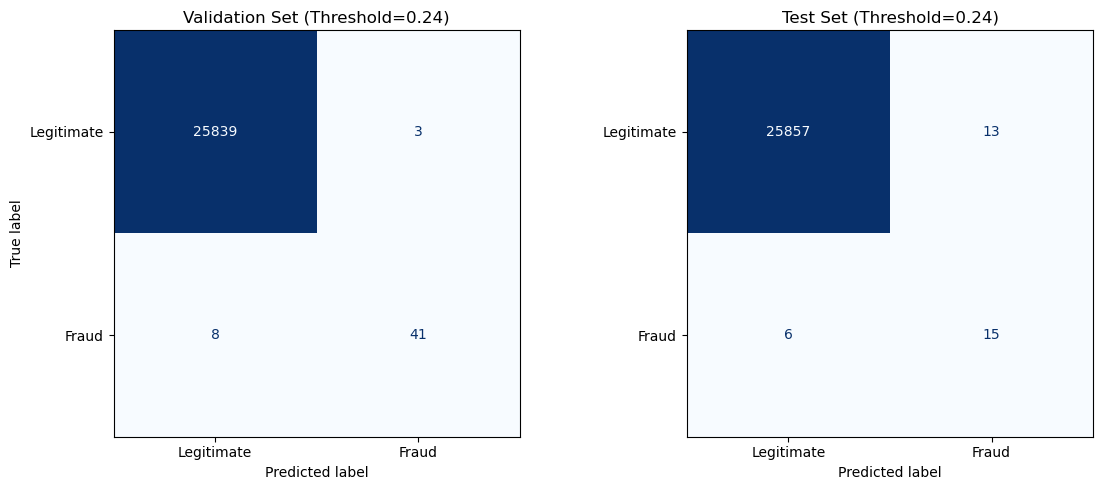

In [98]:
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay, ConfusionMatrixDisplay, confusion_matrix

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
plot_df = pd.DataFrame({
    'score': y_pred,
    'actual': y_valid,
})
plot_df['predicted_class'] = np.where(plot_df['score']>=best_threshold, 1, 0)
cm = confusion_matrix(plot_df['actual'], plot_df['predicted_class'])
disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Legitimate', 'Fraud']
    )
disp.plot(cmap='Blues', colorbar=False, ax=ax[0])
ax[0].set_title(f"Validation Set (Threshold={best_threshold:.2f})", size=12)

y_pred_test = model.predict_proba(X_test)[:, 1]
plot_df = pd.DataFrame({
    'score': y_pred_test,
    'actual': y_test,
})
plot_df['predicted_class'] = np.where(plot_df['score']>=best_threshold, 1, 0)
cm = confusion_matrix(plot_df['actual'], plot_df['predicted_class'])
disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Legitimate', 'Fraud']
    )
disp.plot(cmap='Blues', colorbar=False, ax=ax[1])
ax[1].set_title(f"Test Set (Threshold={best_threshold:.2f})", size=12)
ax[1].set_ylabel('')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=100)

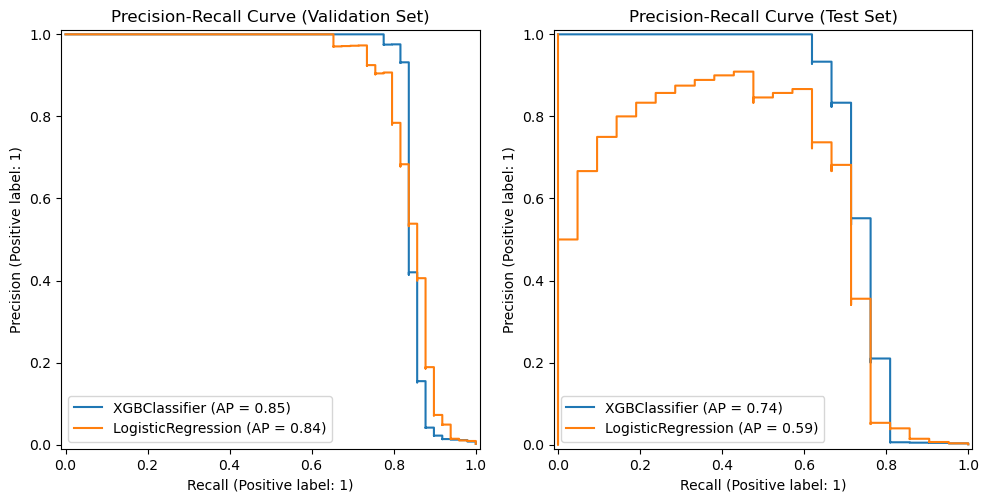

In [105]:
with open('models/logistic.pkl', 'rb') as file:
    logistic_model = pickle.load(file)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
display = PrecisionRecallDisplay.from_estimator(model, X_valid, y_valid, ax=ax[0])
display.ax_.set_title("Precision-Recall Curve (Validation Set)")
display = PrecisionRecallDisplay.from_estimator(logistic_model, X_valid, y_valid, ax=ax[0])

display = PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax[1])
display.ax_.set_title("Precision-Recall Curve (Test Set)")
display = PrecisionRecallDisplay.from_estimator(logistic_model, X_test, y_test, ax=ax[1])

plt.tight_layout()
plt.savefig("precision_recall.png")

### Calibrate Model Outputs to Probabilities, and Simulate the Expected Cost

## Deploy the Model on Gemini Agent Platform, and Set Up Monitoring Processes

Once we are happy with the model we've built, we move the model to production.

In [3]:
!gcloud storage cp models/model.bst gs://bucket-for-everything-in-vertex

I0421 08:05:47.698353 127514526 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(97, generation: 1)
Copying file://models/model.bst to gs://bucket-for-everything-in-vertex/model.bst
  Completed files 1/1 | 520.4kiB/520.4kiB                                      


**Scoring a single transaction**

* The FastAPI app that we deployed to the agent platform outputs the fraud probability for the transaction, and the classification
* The top-5 input features which contributed to the output is also provided

In [121]:
import json
from pathlib import Path
from google.cloud import aiplatform

ENDPOINT_ID = "755815288049500160"

aiplatform.init(project="end-to-end-llm", location="us-west1")
endpoint = aiplatform.Endpoint(ENDPOINT_ID)

example = {
    "V1":-0.4907149334, 
    "V2":-0.5595134754,
    "V3":0.5858813887, 
    "V4":-1.6594389586, 
    "V5":-0.2620417571,  
    "V6":0.6315673033, 
    "V7":0.2742891726, 
    "V8":0.0647268436, 
    "V9":-0.9486028073, 
    "V10":0.2202276049, 
    "V11":0.3461948086, 
    "V12":0.020625631, 
    "V13":0.4213205777, 
    "V14":-0.5124723959, 
    "V15":-1.2151635489, 
    "V16":1.0310268829, 
    "V17":0.0268080147, 
    "V18":-1.0768343333, 
    "V19":1.6866129716, 
    "V20":0.0989435547, 
    "V21":-0.0793086973, 
    "V22":-0.2135445517, 
    "V23":0.1940625095,
    "V24":0.2149394406, 
    "V25":-0.9684615092, 
    "V26":-0.6244339054, 
    "V27":0.1966394897, 
    "V28":0.1490809295, 
    "Amount":175.66
}

response = endpoint.predict(
    instances=[example],
    parameters={"explain": True, "top_k_features": 5}
)
#response.predictions

for k, v in response.predictions[0].items():
    if k == "top_features":
        print("Top Features:")
        for f in v:
            print(f"\t {f['feature']}: {f['value']:.4f}")
            print(f"\t \t Direction: {f["direction"]}")
            print(f"\t \t SHAP Value: {f['shap_value']:.4f}")
    else:
        print(f"{k}: {v}")

Top Features:
	 V4: -1.6594
	 	 Direction: decreases_risk
	 	 SHAP Value: -5.0103
	 V14: -0.5125
	 	 Direction: decreases_risk
	 	 SHAP Value: -1.7194
	 V27: 0.1966
	 	 Direction: decreases_risk
	 	 SHAP Value: -1.1002
	 V12: 0.0206
	 	 Direction: decreases_risk
	 	 SHAP Value: -0.9524
	 V16: 1.0310
	 	 Direction: decreases_risk
	 	 SHAP Value: -0.9300
is_fraud: False
fraud_probability: 1e-06
shap_base_value: 4.668858528137207
threshold: 0.236
